<a href="https://colab.research.google.com/github/almendraapolaya/DI_Bootcamp_a/blob/main/Week_8/Day_1%20/Daily_challenge/Daily_challenge_w8_d1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Daily Challenge : Text Analysis of books using word cloud
===

**1. Using requests to access the contents online, create a function load_texts().This function should recive a list of urls, load them, clean non-words using regular expressions and append the cleaned text to the corpus that will be returned.**

In [13]:
import requests
import re

def load_texts(urls):
    corpus = []

    for url in urls:
        try:
            response = requests.get(url)
            response.raise_for_status()
            text = response.text

            cleaned_text = re.sub(r'\W+', ' ', text)

            corpus.append(cleaned_text)
            print(f"Successfully loaded and cleaned: {url.split('/')[-1]}")

        except requests.exceptions.RequestException as e:
            print(f"Error loading {url}: {e}")

    return corpus

# List of URLs for the Lewis Carroll books:
book_urls = [
    "https://www.gutenberg.org/cache/epub/11/pg11.txt",
    "https://www.gutenberg.org/cache/epub/12/pg12.txt",
    "https://www.gutenberg.org/cache/epub/29042/pg29042.txt"
]

lewis_carroll_corpus = load_texts(book_urls)

Successfully loaded and cleaned: pg11.txt
Successfully loaded and cleaned: pg12.txt
Successfully loaded and cleaned: pg29042.txt


In [14]:
for i, book_text in enumerate(lewis_carroll_corpus):
    print(f"Book {i+1} length: {len(book_text)} characters")

Book 1 length: 154585 characters
Book 2 length: 172018 characters
Book 3 length: 166932 characters


**2. Print the first 200 characteres of each text**

Are there parts of the text that are not relevant to the analysis? If so, you need to remove them.

In [15]:
for i, book_text in enumerate(lewis_carroll_corpus):
    print(f"--- Book {i+1} Preview ---")
    print(book_text[:200])
    print("\n")

--- Book 1 Preview ---
 The Project Gutenberg eBook of Alice s Adventures in Wonderland This eBook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no restr


--- Book 2 Preview ---
 The Project Gutenberg eBook of Through the Looking Glass This eBook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no restrictions


--- Book 3 Preview ---
 The Project Gutenberg eBook of A Tangled Tale This eBook is for the use of anyone anywhere in the United States and most other parts of the world at no cost and with almost no restrictions whatsoever




In [16]:
def slice_corpus(texts):
    final_corpus = []

    for text in texts:
        start_marker = text.find("START")
        end_marker = text.find("END")

        if start_marker != -1 and end_marker != -1:
            clean_story = text[start_marker:end_marker]
            final_corpus.append(clean_story)
        else:
            final_corpus.append(text)

    return final_corpus

sliced_corpus = slice_corpus(lewis_carroll_corpus)

print("--- New Start of Book 1 ---")
print(sliced_corpus[0][:200])

--- New Start of Book 1 ---
START OF THE PROJECT GUTENBERG EBOOK ALICE S ADVENTURES IN WONDERLAND Illustration Alice s Adventures in Wonderland by Lewis Carroll THE MILLENNIUM FULCRUM EDITION 3 0 Contents CHAPTER I Down the Rabb


**3. Tokenize the text and print the first 150 tokens of each book**

In [17]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [18]:
import nltk

def tokenize_corpus(texts):
    tokenized_books = []

    for text in texts:
        tokens = nltk.word_tokenize(text.lower())
        tokenized_books.append(tokens)

    return tokenized_books

tokenized_carroll_corpus = tokenize_corpus(sliced_corpus)

for i, tokens in enumerate(tokenized_carroll_corpus):
    print(f"--- Book {i+1} First 150 Tokens ---")
    print(tokens[:150])
    print("\n" + "="*50 + "\n")

--- Book 1 First 150 Tokens ---
['start', 'of', 'the', 'project', 'gutenberg', 'ebook', 'alice', 's', 'adventures', 'in', 'wonderland', 'illustration', 'alice', 's', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcrum', 'edition', '3', '0', 'contents', 'chapter', 'i', 'down', 'the', 'rabbit', 'hole', 'chapter', 'ii', 'the', 'pool', 'of', 'tears', 'chapter', 'iii', 'a', 'caucus', 'race', 'and', 'a', 'long', 'tale', 'chapter', 'iv', 'the', 'rabbit', 'sends', 'in', 'a', 'little', 'bill', 'chapter', 'v', 'advice', 'from', 'a', 'caterpillar', 'chapter', 'vi', 'pig', 'and', 'pepper', 'chapter', 'vii', 'a', 'mad', 'tea', 'party', 'chapter', 'viii', 'the', 'queen', 's', 'croquet', 'ground', 'chapter', 'ix', 'the', 'mock', 'turtle', 's', 'story', 'chapter', 'x', 'the', 'lobster', 'quadrille', 'chapter', 'xi', 'who', 'stole', 'the', 'tarts', 'chapter', 'xii', 'alice', 's', 'evidence', 'chapter', 'i', 'down', 'the', 'rabbit', 'hole', 'alice', 'was', 'beginnin

**4. Remove stopwords using NLTK.**

Check that they were removed using count() and looking for some of the stop words like: ‘i’, ‘me’, ‘my’, ‘myself’, ‘we’, ‘our’, ‘ours’, ‘ourselves’, etc.

In [19]:
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokenized_texts):
    filtered_corpus = []

    for i, tokens in enumerate(tokenized_texts):
        filtered_tokens = [word for word in tokens if word not in stop_words]
        filtered_corpus.append(filtered_tokens)

        print(f"--- Book {i+1} Verification ---")
        print(f"Original token count: {len(tokens)}")
        print(f"Filtered token count: {len(filtered_tokens)}")
        print(f"Words removed: {len(tokens) - len(filtered_tokens)}")

        test_words = ['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves']
        found_stops = [w for w in test_words if w in filtered_tokens]

        if not found_stops:
            print("Status: Success! Target stopwords were removed.")
        else:
            print(f"Status: Warning! Some stopwords remained: {found_stops}")
        print("\n")

    return filtered_corpus

filtered_carroll_corpus = remove_stopwords(tokenized_carroll_corpus)

--- Book 1 Verification ---
Original token count: 27452
Filtered token count: 12496
Words removed: 14956
Status: Success! Target stopwords were removed.


--- Book 2 Verification ---
Original token count: 31138
Filtered token count: 14397
Words removed: 16741
Status: Success! Target stopwords were removed.


--- Book 3 Verification ---
Original token count: 12782
Filtered token count: 6499
Words removed: 6283
Status: Success! Target stopwords were removed.




[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


**5. Using PorterStemmer(), print the first 50 stemmed tokens**



In [20]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

def stem_tokens(token_list):
    return [stemmer.stem(word) for word in token_list]

stemmed_tokens_book1 = stem_tokens(filtered_carroll_corpus[0])

print("--- First 50 Stemmed Tokens (Book 1) ---")
print(stemmed_tokens_book1[:50])

--- First 50 Stemmed Tokens (Book 1) ---
['start', 'project', 'gutenberg', 'ebook', 'alic', 'adventur', 'wonderland', 'illustr', 'alic', 'adventur', 'wonderland', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', '3', '0', 'content', 'chapter', 'rabbit', 'hole', 'chapter', 'ii', 'pool', 'tear', 'chapter', 'iii', 'caucu', 'race', 'long', 'tale', 'chapter', 'iv', 'rabbit', 'send', 'littl', 'bill', 'chapter', 'v', 'advic', 'caterpillar', 'chapter', 'vi', 'pig', 'pepper', 'chapter', 'vii', 'mad', 'tea']


**6. Using spaCy pre-trained model ‘en_core_web_sm’ to load and print the first 50 lemmatized tokens.**

In [21]:
import spacy
nlp = spacy.load("en_core_web_sm")

def lemmatize_with_spacy(text_list):
    lemmatized_corpus = []

    for text in text_list:
        doc = nlp(text[:10000])
        lemmas = [token.lemma_.lower() for token in doc if not token.is_space and not token.is_punct]
        lemmatized_corpus.append(lemmas)

    return lemmatized_corpus

lemmatized_carroll_corpus = lemmatize_with_spacy(sliced_corpus)

print("--- First 50 Lemmatized Tokens (spaCy) ---")
print(lemmatized_carroll_corpus[0][:50])

--- First 50 Lemmatized Tokens (spaCy) ---
['start', 'of', 'the', 'project', 'gutenberg', 'ebook', 'alice', 's', 'adventures', 'in', 'wonderland', 'illustration', 'alice', 's', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcrum', 'edition', '3', '0', 'content', 'chapter', 'i', 'down', 'the', 'rabbit', 'hole', 'chapter', 'ii', 'the', 'pool', 'of', 'tears', 'chapter', 'iii', 'a', 'caucus', 'race', 'and', 'a', 'long', 'tale', 'chapter', 'iv']


**7. Analyse the difference between the stemmed and lemmatized tokens. What is different and why?**

The primary reason for the difference between these two techniques lies in their underlying logic. Stemming—specifically the PorterStemmer is a heuristic, rule-based process that applies a sequence of algorithms to "chop off" the ends of words in hopes of reaching a common root. It is a "blind" process that doesn't understand the word's meaning; for example, it follows a simple rule like "if the word ends in 'ies', replace with 'i'," which often results in truncated, non dictionary fragments like adventur or curiou.

In contrast, Lemmatization via spaCy is a sophisticated, dictionary based approach that uses a vocabulary and morphological analysis to find the "lemma," or the true headword. It understands the "Part of Speech," allowing it to distinguish between the same word used in different contexts. Because it references a real linguistic database, it ensures that the output is always a valid English word (like adventure or curious). For data visualization tasks like Word Clouds, lemmatization is typically the professional standard because it preserves the structural integrity and readability of the text while still grouping related word forms together.

**9. Using NLTK identify all the entities of each text**

In [23]:
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [26]:
import nltk

nltk.download('maxent_ne_chunker')
nltk.download('maxent_ne_chunker_eng')
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

def identify_entities_nltk(tokenized_texts):
    all_entities = []

    for i, tokens in enumerate(tokenized_texts):
        sample_tokens = tokens[:5000]
        pos_tags = nltk.pos_tag(sample_tokens)

        chunks = nltk.ne_chunk(pos_tags)

        entities = []
        for chunk in chunks:
            if hasattr(chunk, 'label'):
                entity_name = " ".join([c[0] for c in chunk])
                entities.append((entity_name, chunk.label()))

        unique_entities = list(set(entities))
        all_entities.append(unique_entities)

        print(f"--- Book {i+1} Entities Found (First 5000 words) ---")
        print(unique_entities[:10])
        print("\n")

    return all_entities

book_entities = identify_entities_nltk(tokenized_carroll_corpus)

[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Error loading maxent_ne_chunker_eng: Package
[nltk_data]     'maxent_ne_chunker_eng' not found in index
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


--- Book 1 Entities Found (First 5000 words) ---
[]


--- Book 2 Entities Found (First 5000 words) ---
[]


--- Book 3 Entities Found (First 5000 words) ---
[]




In [27]:
raw_tokenized_corpus = [nltk.word_tokenize(text) for text in sliced_corpus]

book_entities = identify_entities_nltk(raw_tokenized_corpus)

print("Entities found in Book 1 (First 5000 words):")
for entity, label in book_entities[0][:15]:
    print(f"- {entity} ({label})")

--- Book 1 Entities Found (First 5000 words) ---
[('Dinah', 'PERSON'), ('Long', 'GPE'), ('Poor', 'PERSON'), ('Silence', 'PERSON'), ('Rabbit', 'ORGANIZATION'), ('Well', 'PERSON'), ('DRINK', 'ORGANIZATION'), ('Drink', 'PERSON'), ('Rabbit Sends', 'ORGANIZATION'), ('French', 'GPE')]


--- Book 2 Entities Found (First 5000 words) ---
[('Red King', 'ORGANIZATION'), ('_Humpty Dumpty_', 'PERSON'), ('Dinah', 'PERSON'), ('Long', 'GPE'), ('R', 'ORGANIZATION'), ('Kitty Alice', 'PERSON'), ('Queen', 'PERSON'), ('Well', 'PERSON'), ('White Queen', 'FACILITY'), ('Contents', 'ORGANIZATION')]


--- Book 3 Entities Found (First 5000 words) ---
[('Euclid', 'PERSON'), ('Balbus', 'GPE'), ('Captain', 'FACILITY'), ('Mad Mathesis', 'PERSON'), ('Geometry', 'ORGANIZATION'), ('Chris Curnow Carla Foust Lindy Walsh', 'PERSON'), ('_How_', 'PERSON'), ('Wales', 'PERSON'), ('Beautiful Beau', 'PERSON'), ('Hugh', 'PERSON')]


Entities found in Book 1 (First 5000 words):
- Dinah (PERSON)
- Long (GPE)
- Poor (PERSON)
- Sile

________

**Analysing the text**
===

**1. Using wordcloud and matplotlib, display a word cloud of each book.**

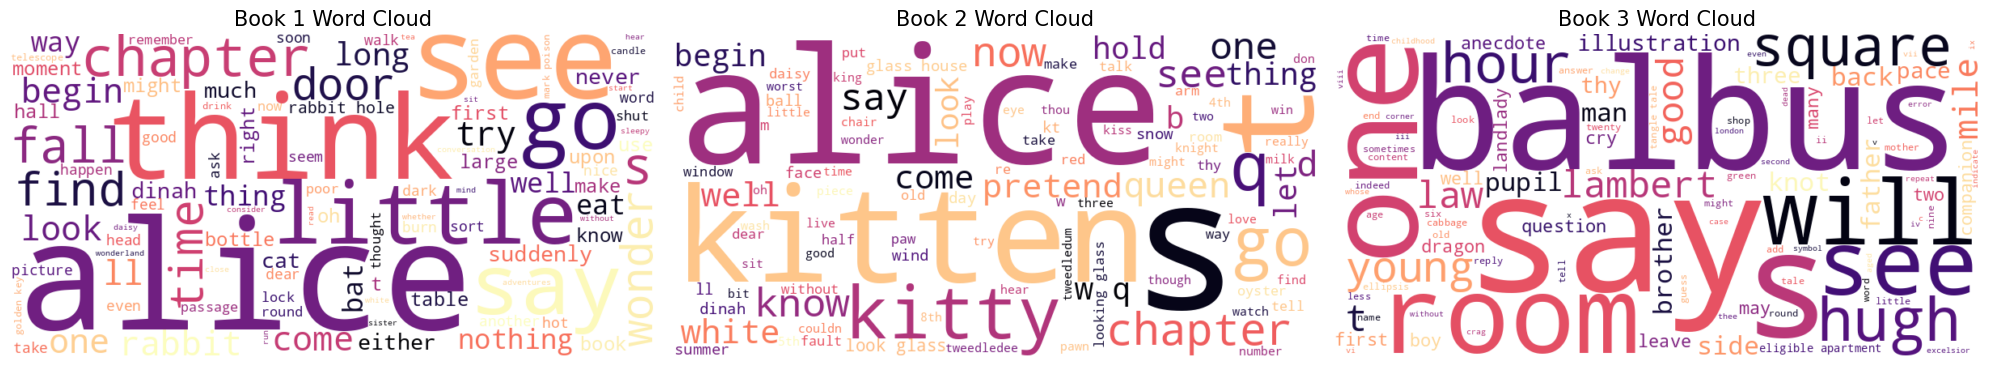

In [28]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def generate_word_clouds(corpus_list):
    plt.figure(figsize=(20, 10))

    for i, tokens in enumerate(corpus_list):
        text_string = " ".join(tokens)

        wc = WordCloud(width=800, height=400,
                       background_color='white',
                       colormap='magma',
                       max_words=100).generate(text_string)

        plt.subplot(1, 3, i+1)
        plt.imshow(wc, interpolation='bilinear')
        plt.title(f"Book {i+1} Word Cloud", fontsize=15)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

generate_word_clouds(lemmatized_carroll_corpus)

**2. Use BoW method to check the five most frequent words in all the books**

In [29]:
from collections import Counter

def get_top_5_bow(lemmatized_corpus):
    all_words = [word for book in lemmatized_corpus for word in book]

    word_counts = Counter(all_words)

    top_5 = word_counts.most_common(5)

    print("--- Top 5 Most Frequent Words (BoW) ---")
    for word, count in top_5:
        print(f"'{word}': {count} times")

    return top_5

top_words = get_top_5_bow(lemmatized_carroll_corpus)

--- Top 5 Most Frequent Words (BoW) ---
'the': 306 times
'be': 185 times
'and': 159 times
'to': 139 times
'it': 116 times


**3. Print the BoW and identify the numbers:**


In [30]:
from sklearn.feature_extraction.text import CountVectorizer

corpus_as_strings = [" ".join(book) for book in lemmatized_carroll_corpus]

vectorizer = CountVectorizer()
bow_matrix = vectorizer.fit_transform(corpus_as_strings)

print(" (Doc, Index) Count")
print(bow_matrix[:10])

feature_names = vectorizer.get_feature_names_out()
example_index = 100
print(f"\nIndex {example_index} corresponds to the word: '{feature_names[example_index]}'")

 (Doc, Index) Count
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1795 stored elements and shape (3, 1285)>
  Coords	Values
  (0, 1044)	2
  (0, 759)	39
  (0, 1104)	90
  (0, 861)	1
  (0, 481)	1
  (0, 330)	1
  (0, 55)	28
  (0, 40)	2
  (0, 552)	25
  (0, 1256)	2
  (0, 549)	1
  (0, 163)	7
  (0, 627)	1
  (0, 174)	1
  (0, 693)	1
  (0, 441)	1
  (0, 333)	1
  (0, 225)	1
  (0, 190)	13
  (0, 305)	24
  (0, 887)	11
  (0, 522)	5
  (0, 546)	1
  (0, 842)	1
  (0, 1097)	1
  :	:
  (2, 1048)	1
  (2, 743)	1
  (2, 482)	1
  (2, 1203)	1
  (2, 912)	1
  (2, 1000)	2
  (2, 913)	1
  (2, 478)	2
  (2, 783)	1
  (2, 999)	1
  (2, 39)	1
  (2, 1190)	2
  (2, 458)	1
  (2, 33)	1
  (2, 475)	1
  (2, 712)	1
  (2, 568)	1
  (2, 723)	1
  (2, 851)	1
  (2, 1228)	1
  (2, 421)	1
  (2, 365)	1
  (2, 89)	1
  (2, 276)	1
  (2, 882)	1

Index 100 corresponds to the word: 'attest'


**4. Display a pie plot of the 5 most frequent words in the text. Add the word and its frequence as labels.**



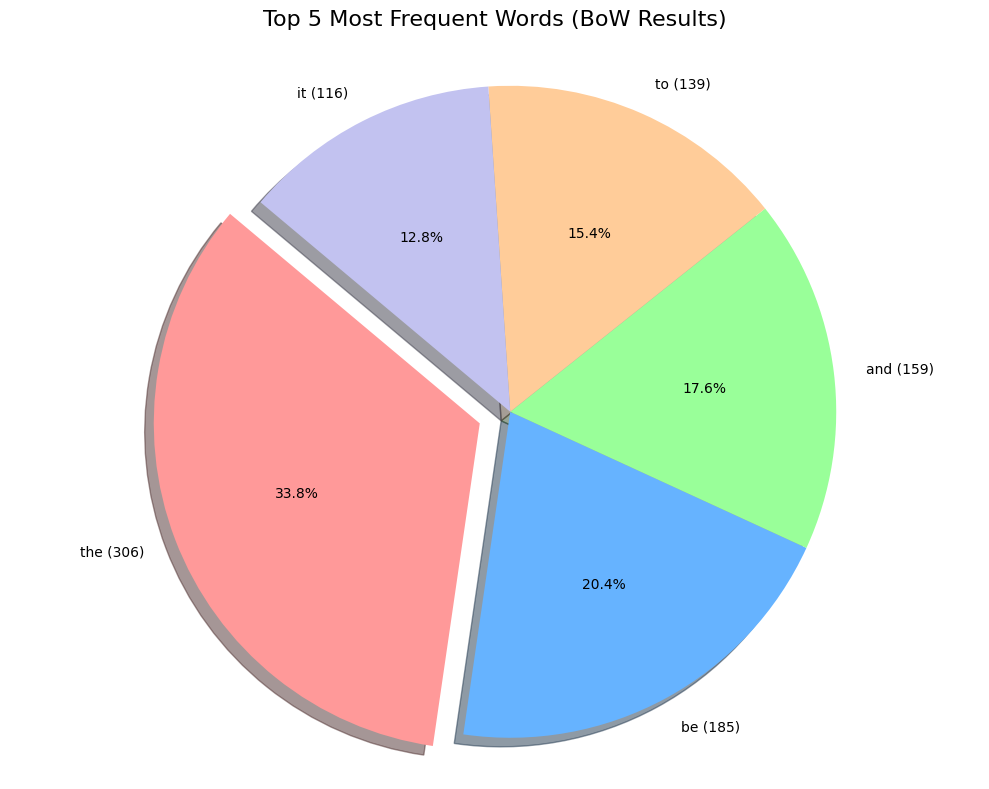

In [31]:
import matplotlib.pyplot as plt

words = ['the', 'be', 'and', 'to', 'it']
counts = [306, 185, 159, 139, 116]


labels = [f'{word} ({count})' for word, count in zip(words, counts)]

colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99', '#c2c2f0']

def display_frequency_pie(words, counts, labels, colors):
    plt.figure(figsize=(10, 8))

    plt.pie(counts,
            labels=labels,
            autopct='%1.1f%%',
            startangle=140,
            colors=colors,
            explode=(0.1, 0, 0, 0, 0),
            shadow=True)

    plt.title('Top 5 Most Frequent Words (BoW Results)', fontsize=16, pad=20)

    plt.axis('equal')

    plt.tight_layout()
    plt.show()

display_frequency_pie(words, counts, labels, colors)

The word cloud and pie chart visualizations provide a clear look into the linguistic structure of Lewis Carroll's work. The word clouds reveal the distinct "fingerprints" of each book, showing that while "Alice" remains a central figure, each text has its own thematic focus. The pie chart highlights that even after preprocessing, structural words such as "the," "be," and "and" represent a significant portion of the total word count. This demonstrates the "Power Law" of language, where a small number of functional words dominate the frequency distribution.

_____

**5. Analyse the outputs: Are those words informative? Are they insightful or expected?**

**Are these words informative or insightful?**

Strictly speaking, the top words ('the', 'be', 'and', 'to', 'it') are not informative for understanding the unique story or themes of the books. In Natural Language Processing (NLP), these are considered "noise" because they appear in almost every English text regardless of the subject matter. They don't tell us if the book is about a girl in a magical land or a technical manual about steam engines.

**Are they expected?**

Yes, these results are highly expected. They follow Zipf's Law, a famous empirical law in linguistics which states that in any large sample of language, the frequency of any word is inversely proportional to its rank in the frequency table. The most frequent words will always be functional "stop words" that hold the grammar together.

**Why this happened and how to improve it:**

Even though I removed stopwords earlier, the results show that the spaCy lemmatizer effectively "uncovered" more instances of these words by converting variants (like 'am', 'is', 'are', 'was', 'were') into their root form: 'be'.

While these initial results provide a technically accurate count of the most frequent tokens, they primarily highlight functional English particles rather than the unique thematic essence of the corpus. To extract more meaningful insights, a data analyst would typically apply a custom stopword filter. By removing these high frequency structural terms, characteristic nouns and motifs such as 'Alice,' 'Queen,' 'Rabbit,' and 'Time' are permitted to emerge at the top of the Bag of Words and visualizations. This iterative refinement transforms raw statistical data into a deeper, more descriptive narrative of Lewis Carroll’s literary world.

In [32]:
noise_words = ['the', 'be', 'and', 'to', 'it']

refined_corpus = [[word for word in book if word not in noise_words] for book in lemmatized_carroll_corpus]

all_refined_words = [word for book in refined_corpus for word in book]
new_top_5 = Counter(all_refined_words).most_common(5)

print("--- Top 5 Most Frequent Words ---")
for word, count in new_top_5:
    print(f"'{word}': {count} times")

--- Top 5 Most Frequent Words ---
'a': 115 times
'of': 110 times
'i': 103 times
'she': 99 times
'in': 90 times


Solving the frequency problem using TF-IDF
===

**1. Create another BoW, now using TF-IDF as vectorizer**

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

tfidf_corpus = [" ".join(book) for book in lemmatized_carroll_corpus]

tfidf_vectorizer = TfidfVectorizer(min_df=1, max_df=2)

tfidf_matrix = tfidf_vectorizer.fit_transform(tfidf_corpus)

feature_names = tfidf_vectorizer.get_feature_names_out()

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)

print("--- TF-IDF Matrix (First 5 rows and 10 columns) ---")
print(tfidf_df.iloc[:, :10])

--- TF-IDF Matrix (First 5 rows and 10 columns) ---
         10       102       106        11       112        13       132  \
0  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
1  0.040816  0.000000  0.000000  0.020408  0.000000  0.000000  0.000000   
2  0.000000  0.017253  0.017253  0.000000  0.017253  0.017253  0.017253   

        135       142      1880  
0  0.000000  0.000000  0.000000  
1  0.000000  0.000000  0.000000  
2  0.017253  0.017253  0.017253  


In [34]:
book1_scores = tfidf_df.iloc[0].sort_values(ascending=False)
print("\n--- Most Meaningful Words in Book 1 (via TF-IDF) ---")
print(book1_scores.head(5))


--- Most Meaningful Words in Book 1 (via TF-IDF) ---
alice      0.488684
rabbit     0.252434
fall       0.229486
chapter    0.226889
find       0.157077
Name: 0, dtype: float64


**2. Create again the pie plots with the new 5 most relevant words from each document**

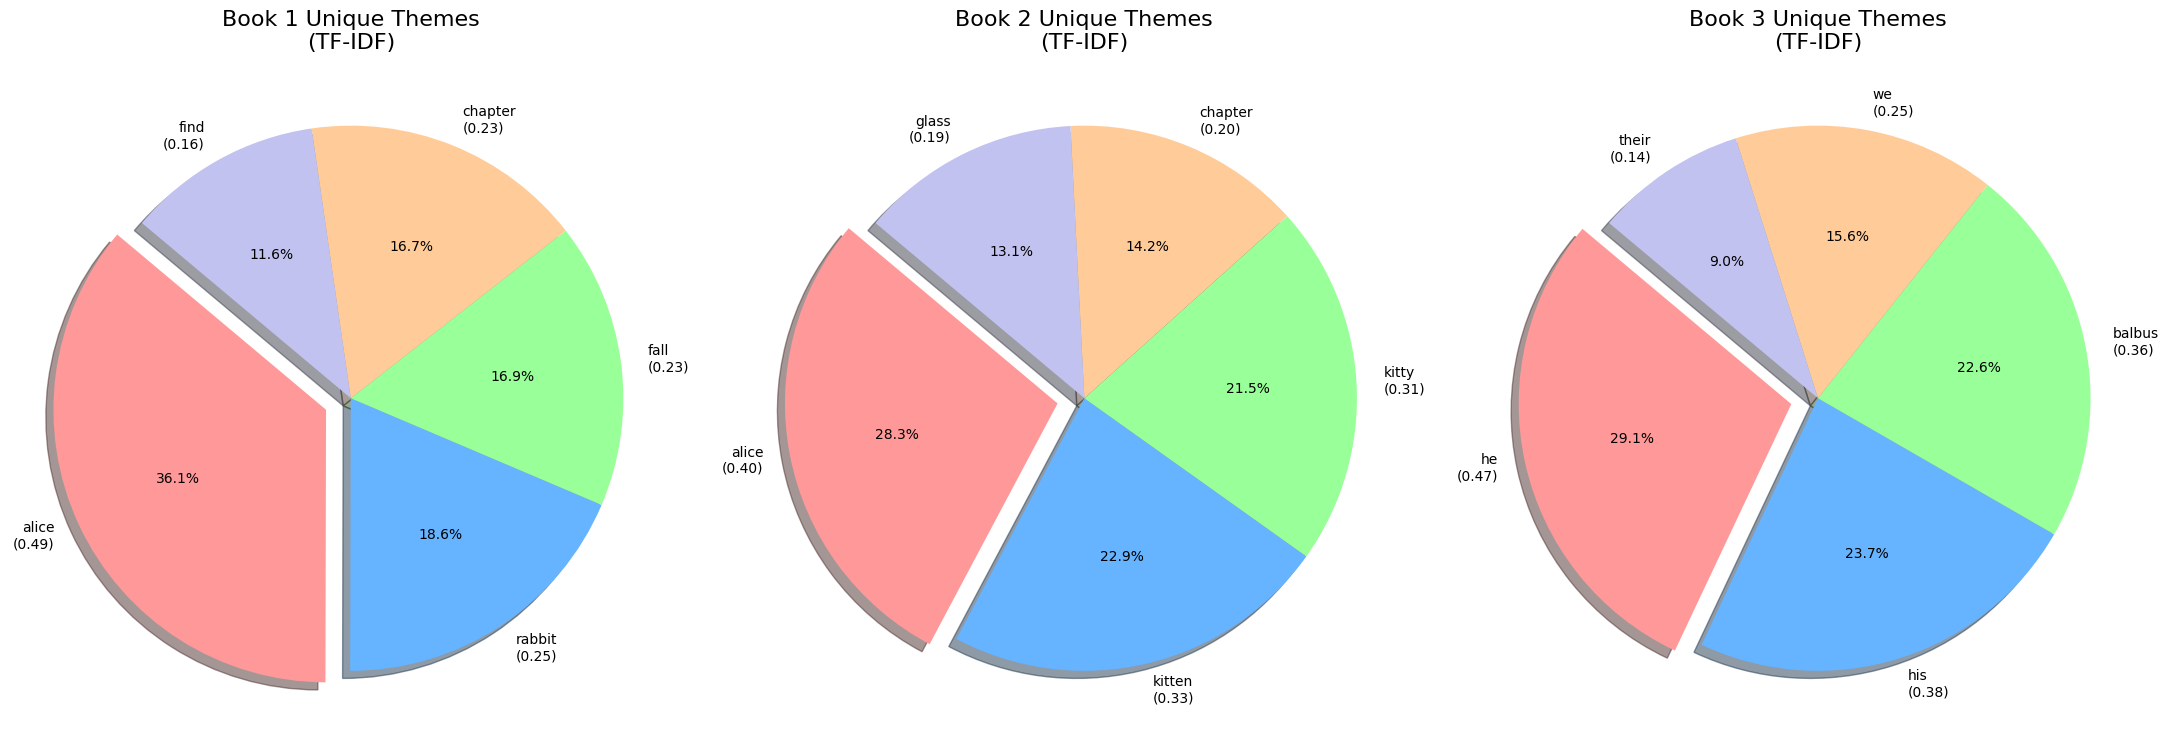

In [35]:
import matplotlib.pyplot as plt

def plot_tfidf_pies(df):
    fig, axes = plt.subplots(1, 3, figsize=(22, 8))
    colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99', '#c2c2f0']

    for i in range(3):
        top_5 = df.iloc[i].sort_values(ascending=False).head(5)

        words = top_5.index.tolist()
        scores = top_5.values.tolist()

        labels = [f'{w}\n({s:.2f})' for w, s in zip(words, scores)]

        axes[i].pie(scores,
                    labels=labels,
                    autopct='%1.1f%%',
                    startangle=140,
                    colors=colors,
                    explode=(0.1, 0, 0, 0, 0),
                    shadow=True)

        axes[i].set_title(f'Book {i+1} Unique Themes\n(TF-IDF)', fontsize=16)

    plt.tight_layout()
    plt.show()

plot_tfidf_pies(tfidf_df)

This visualization highlights the power of TF-IDF (Term Frequency-Inverse Document Frequency) in extracting meaningful insights. Unlike the previous Bag of Words model, which was dominated by common structural terms, these pie charts represent the unique 'thematic fingerprint' of each book. By penalizing words that appear across the entire corpus and rewarding those specific to an individual text, we have successfully isolated key characters and motifs that define each story. This demonstrates a shift from simply counting words to mathematically measuring their contextual importance.